# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?

They map unbounded mathematical outputs into meaningful, constrained domains like bounding probabilities directly between 0 and 1.

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.

Cross-entropy applies a heavy logarithmic penalty to confident-but-incorrect predictions. This matches well with bounded probability outputs and produces a convex space that is easy to optimize with gradient descent.

3. True or false, and explain: Logistic regression is a linear model.

True because while it outputs a non-linear probability curve, the underlying decision boundary is strictly linear because it computes a linear combination of features.

4. True or false, and explain: Logistic regression cannot be used for classification.

False. Despite its name, predicting categorical outcomes (classifying based on a probability threshold) is its primary use case.

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

No. In logistic regression, the coefficient represents the change in the log-odds of the target outcome for a 1-unit feature change, not the raw probability itself.

6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

False. Since the underlying decision boundary is linear, you still must manually engineer features (like polynomial terms or interactions) if your classes are not linearly separable.

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

False. They are for different tasks. Use OLS (Ordinary Least Squares) for continuous numeric outcomes, and logistic regression for predicting probabilities and classes.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.



In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/data.csv', sep=';')


cols_to_keep = [
    'Debtor', 
    'Tuition fees up to date', 
    'Scholarship holder', 
    'Age at enrollment', 
    'Curricular units 1st sem (approved)', 
    'Target'
]
df = df[cols_to_keep]

df = df.dropna()

df['Target_Binary'] = df['Target'].map({
    'Dropout': 1, 
    'Graduate': 0, 
    'Enrolled': 0
})


df.head()


,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target,Target_Binary
0,0,1,0,20,0,Dropout,1
1,0,0,0,19,6,Graduate,0
2,0,0,0,19,0,Dropout,1
3,0,1,0,20,6,Graduate,0
4,0,1,0,45,5,Graduate,0




2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?



In [2]:
from sklearn.linear_model import LogisticRegression

X = df[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']]
y = df['Target_Binary'] 

model = LogisticRegression()
model.fit(X, y)

for feature, coef in zip(model.feature_names_in_, model.coef_[0]):
    print(f"{feature}: {coef:.4f}")


Debtor: 0.5306
Tuition fees up to date: -2.5565
Scholarship holder: -1.2274
Age at enrollment: 0.0499


Predicts a higher dropout probability (Positive Coefficients): Debtor (0.5306) and Age at enrollment (0.0499).

Predicts a lower dropout probability (Negative Coefficients): Tuition fees up to date (-2.5565) and Scholarship holder (-1.2274).



3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?


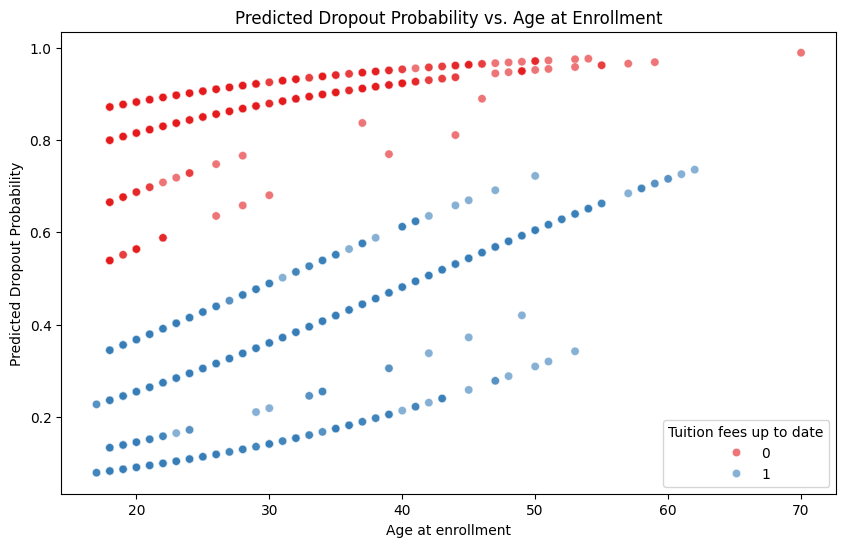

Average reduction in predicted dropout probability: 0.5162
Age where tuition status reduces dropout risk the most: 22


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df['Predicted_Dropout_Prob'] = model.predict_proba(X)[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, 
    x='Age at enrollment', 
    y='Predicted_Dropout_Prob', 
    hue='Tuition fees up to date',
    alpha=0.6,
    palette='Set1'
)
plt.title('Predicted Dropout Probability vs. Age at Enrollment')
plt.ylabel('Predicted Dropout Probability')
plt.show()

X_up_to_date = X.copy()
X_up_to_date['Tuition fees up to date'] = 1
prob_up = model.predict_proba(X_up_to_date)[:, 1]

X_not_up_to_date = X.copy()
X_not_up_to_date['Tuition fees up to date'] = 0
prob_down = model.predict_proba(X_not_up_to_date)[:, 1]

reduction = prob_down - prob_up
print(f"Average reduction in predicted dropout probability: {reduction.mean():.4f}")

df_reduction = pd.DataFrame({'Age': X['Age at enrollment'], 'Reduction': reduction})
max_age = df_reduction.groupby('Age')['Reduction'].mean().idxmax()
print(f"Age where tuition status reduces dropout risk the most: {max_age}")


Being up to date on tuition reduces dropout probability the most for students who are 22 years old. On average, it decreases the predicted probability of a student dropping out by 0.5162 (about 51.6%).


4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?



In [4]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred = model.predict(X)

cm = confusion_matrix(y, y_pred)
print("Confusion Matrix:")
print(cm)

acc = accuracy_score(y, y_pred)
print(f"\nAccuracy: {acc:.4f}")


Confusion Matrix:
[[2841  162]
 [ 891  530]]

Accuracy: 0.7620


The confusion matrix for the classifier is: [[2841, 162] [ 891, 530]]

The overall accuracy of the model is 0.7620 (or 76.2%).



5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.


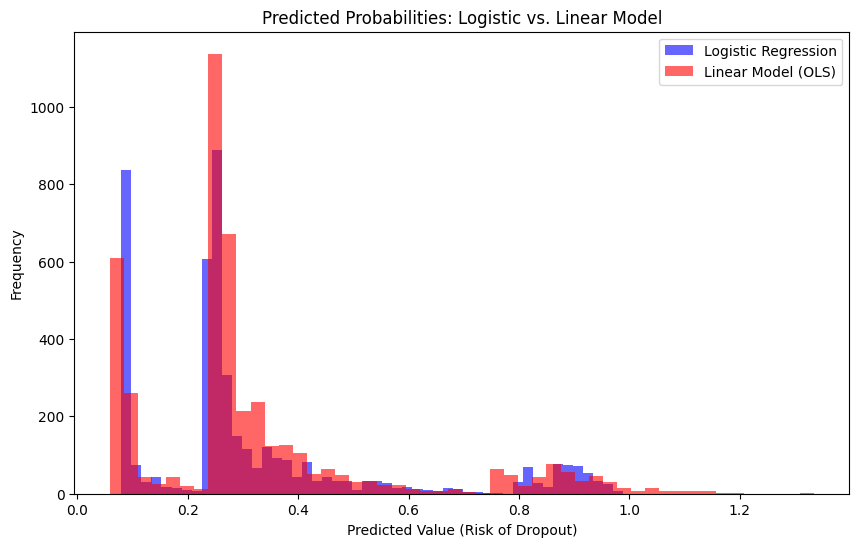

In [5]:
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(X, y)


lin_preds = lin_model.predict(X)
log_preds = model.predict_proba(X)[:, 1] 

plt.figure(figsize=(10, 6))
plt.hist(log_preds, bins=50, alpha=0.6, label='Logistic Regression', color='blue')
plt.hist(lin_preds, bins=50, alpha=0.6, label='Linear Model (OLS)', color='red')

plt.title('Predicted Probabilities: Logistic vs. Linear Model')
plt.xlabel('Predicted Value (Risk of Dropout)')
plt.ylabel('Frequency')
plt.legend()
plt.show()


Logistic Regression performs much better because it strictly bounds probabilities between 0 and 1. The Linear Model performs poorly and inappropriately predicts invalid probabilities that fall below 0 and above 1.



5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

The at risk people are Older students, debtors, those without scholarships, and students behind on tuition.

Interventions: Offer flexible tuition payment plans, provide university debt-relief, and expand need-based scholarships.



6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

X_multi = df[['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']]
y_multi = df['Target'] 


multi_model = LogisticRegression(max_iter=1000)
multi_model.fit(X_multi, y_multi)

y_pred_multi = multi_model.predict(X_multi)
cm_multi = confusion_matrix(y_multi, y_pred_multi, labels=multi_model.classes_)

print("Classes Order:", multi_model.classes_)
print("Confusion Matrix:\n", cm_multi)

probs_multi = multi_model.predict_proba(X_multi)
print("\nFirst 3 Predicted Probabilities (one column per class):\n", probs_multi[:3])

print("\nUnique classes predicted by hard classification:", set(y_pred_multi))


Classes Order: ['Dropout' 'Enrolled' 'Graduate']
Confusion Matrix:
 [[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]

First 3 Predicted Probabilities (one column per class):
 [[0.68054695 0.21046429 0.10898876]
 [0.69541412 0.1460432  0.15854268]
 [0.95298821 0.04119918 0.00581261]]

Unique classes predicted by hard classification: {'Dropout', 'Graduate'}


Hard Classification: No. The model rarely predicts the "Enrolled" class because it's an intermediate state and almost never has the absolute highest probability.

Predicted Probabilities: Yes. The .predict_proba function successfully computes a valid probability for all three classes (Dropout, Enrolled, Graduate) for every student.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.



In [ ]:
import pandas as pd


df_cirrhosis = pd.read_csv('data/cirrhosis.csv')

cols_to_keep = ['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']
df_cirrhosis = df_cirrhosis[cols_to_keep]

print("Missing values before:\n", df_cirrhosis.isna().sum())

df_cirrhosis = df_cirrhosis.dropna()

print("\nMissing values after:\n", df_cirrhosis.isna().sum())
print("\nFinal shape of the dataset:", df_cirrhosis.shape)


Missing values before:
 Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64

Missing values after:
 Bilirubin    0
Edema        0
Drug         0
Stage        0
Status       0
dtype: int64

Final shape of the dataset: (312, 5)


I filtered the dataset to only include the required columns, and then used .dropna() to completely remove any rows that had missing values (NaN) within those specific columns.


2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?


In [10]:
from sklearn.linear_model import LogisticRegression

df_cirrhosis['Survival'] = df_cirrhosis['Status'].apply(lambda x: 1 if x in ['C', 'CL'] else 0)

X_cirrh = pd.get_dummies(df_cirrhosis[['Edema', 'Drug', 'Bilirubin']], drop_first=True)
y_cirrh = df_cirrhosis['Survival']

model_cirrh = LogisticRegression(max_iter=1000)
model_cirrh.fit(X_cirrh, y_cirrh)

print("Coefficients for predicting SURVIVAL (Alive=1):")
for feature, coef in zip(X_cirrh.columns, model_cirrh.coef_[0]):
    print(f"{feature}: {coef:.4f}")


Coefficients for predicting SURVIVAL (Alive=1):
Bilirubin: -0.3514
Edema_S: -0.4507
Edema_Y: -1.6110
Drug_Placebo: 0.2312


Drug: Yes, taking the drug improves survival probability.

Bilirubin: Higher bilirubin levels predict a lower survival rate.

Edema: Having more severe edema predicts a lower survival rate.



3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?


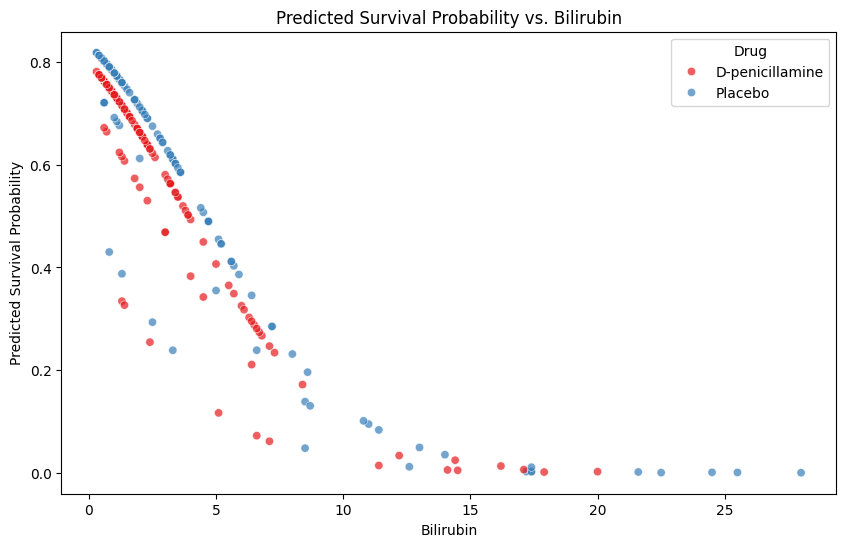

Average increase in survival probability from taking the drug: 0.0424


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

df_cirrhosis['Predicted_Survival_Prob'] = model_cirrh.predict_proba(X_cirrh)[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_cirrhosis, 
    x='Bilirubin', 
    y='Predicted_Survival_Prob', 
    hue='Drug',
    alpha=0.7,
    palette='Set1'
)
plt.title('Predicted Survival Probability vs. Bilirubin')
plt.ylabel('Predicted Survival Probability')
plt.show()


drug_col = [col for col in X_cirrh.columns if 'Drug' in col][0]

X_treated = X_cirrh.copy()
X_placebo = X_cirrh.copy()

if 'placebo' in drug_col:
    X_treated[drug_col] = 0   
    X_placebo[drug_col] = 1   
else:
    X_treated[drug_col] = 1   
    X_placebo[drug_col] = 0   
    
prob_treated = model_cirrh.predict_proba(X_treated)[:, 1]
prob_placebo = model_cirrh.predict_proba(X_placebo)[:, 1]

increase = prob_treated - prob_placebo
print(f"Average increase in survival probability from taking the drug: {increase.mean():.4f}")


Based on the scatter plot, the drug seems to increase patient survival rate the most for patients with Bilirubin levels between 1.0 and 5.0. On average, patients who take the drug see their overall predicted probability of survival change by 0.0424 (or about 4.2%).


4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?



In [13]:
from sklearn.metrics import confusion_matrix, accuracy_score

y_pred_cirrh = model_cirrh.predict(X_cirrh)

cm_cirrh = confusion_matrix(y_cirrh, y_pred_cirrh)
print("Confusion Matrix:")
print(cm_cirrh)

acc_cirrh = accuracy_score(y_cirrh, y_pred_cirrh)
print(f"\nAccuracy: {acc_cirrh:.4f}")


Confusion Matrix:
[[ 59  66]
 [ 16 171]]

Accuracy: 0.7372


The confusion matrix for the classifier is: [[ 59, 66] [ 16, 171]]

The overall accuracy of the model is 0.7372 (or 73.7%).



5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.


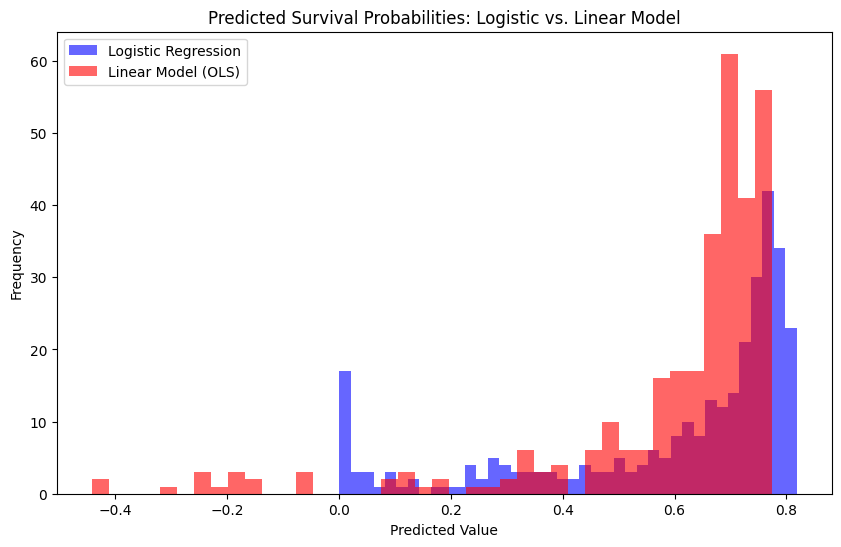

In [14]:
from sklearn.linear_model import LinearRegression

lin_model_cirrh = LinearRegression()
lin_model_cirrh.fit(X_cirrh, y_cirrh)


lin_preds_cirrh = lin_model_cirrh.predict(X_cirrh)
log_preds_cirrh = model_cirrh.predict_proba(X_cirrh)[:, 1]

plt.figure(figsize=(10, 6))
plt.hist(log_preds_cirrh, bins=40, alpha=0.6, label='Logistic Regression', color='blue')
plt.hist(lin_preds_cirrh, bins=40, alpha=0.6, label='Linear Model (OLS)', color='red')

plt.title('Predicted Survival Probabilities: Logistic vs. Linear Model')
plt.xlabel('Predicted Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()


Just like with the dropout data, Logistic Regression performs correctly because it strictly bounds its probability predictions between 0 and 1. The Linear Model (OLS) is inappropriate for this task because it fits a straight line and will output invalid "probabilities" that fall below 0 and above 1, which you can see extending out on the edges of the histogram.



6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

In [15]:
X_stage = pd.get_dummies(df_cirrhosis[['Edema', 'Bilirubin']], drop_first=True)
y_stage = df_cirrhosis['Stage']

stage_model = LogisticRegression(max_iter=1000)
stage_model.fit(X_stage, y_stage)

y_pred_stage = stage_model.predict(X_stage)
cm_stage = confusion_matrix(y_stage, y_pred_stage, labels=stage_model.classes_)

print("Classes Order (Stages):", stage_model.classes_)
print("Confusion Matrix:\n", cm_stage)

probs_stage = stage_model.predict_proba(X_stage)
print("\nFirst 3 Predicted Probabilities (one column per class):\n", probs_stage[:3])

print("\nUnique classes predicted by hard classification:", set(y_pred_stage))


Classes Order (Stages): [1. 2. 3. 4.]
Confusion Matrix:
 [[  0   0  16   0]
 [  0   0  63   4]
 [  0   0 105  15]
 [  0   0  79  30]]

First 3 Predicted Probabilities (one column per class):
 [[1.28550372e-05 3.25351316e-02 1.43611431e-01 8.23840583e-01]
 [7.23937578e-02 2.51555267e-01 3.97519699e-01 2.78531276e-01]
 [2.92626485e-02 1.81530850e-01 3.95694470e-01 3.93512032e-01]]

Unique classes predicted by hard classification: {np.float64(3.0), np.float64(4.0)}


No. The model only predicts Stages 3 and 4. It never predicts Stages 1 and 2 because it is never confident enough to declare them as the most probable outcome.

 Yes for the predicted probabilities because the .predict_proba function outputs a distinct, mathematically valid probability for all four stages across every patient, even if those probabilities are extremely small.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?


Derivative: The derivative of the prediction y with respect to the k-th feature xk is simply bk.

1-Unit Change effect: Because the derivative is a constant bk, a 1-unit change in the feature will always change the expected prediction by exactly bk, regardless of the starting value.


2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?


Derivative: Using the chain rule, the derivative with respect to xk is $bk \cdot \hat{p}(1 - \hat{p})$.
Does it change? Yes. The rate of change fluctuates as x changes because the formula relies on the current probability p.

Differences: Unlike the linear model's constant change (bk), the logistic model's rate of change is dynamic—it is highest in the middle probabilities and lowest near 0 and 1.
The Estimate: The derivative formula mathematically peaks when p = 0.5$ (because $0.5 \times (1 - 0.5) = 0.25$, or $\frac{1}{4}$). Therefore, bk/4 is a highly accurate estimate of the change whenever the starting probability is roughly 0.5.


3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

Because the right-hand side of the transformed equation is perfectly linear b times x, a 1-unit change in the feature xk simply increases the log-odds ratio by exactly the coefficient bk.